# Phase 7 - Statistics & Forecasting

The Nomura JD names "statistics knowledge and applicability to real-life use cases"
and "statistical analysis and forecasting". This notebook gives defensible answers:
descriptive stats, correlation (with the causation caveat), z-scores, a 95%
confidence interval, and a forecast with an explicit assumption about the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style="whitegrid")
os.makedirs("../outputs/figures", exist_ok=True)
df = pd.read_csv("../data/cleaned/zomato_clean.csv")
print("Loaded:", df.shape)

Loaded: (224520, 12)


### 1 - Descriptive statistics
Mean/median show central tendency; variance/std-dev show spread. Std-dev is in the
original units (rating points), so it's what we communicate to stakeholders.

In [2]:
print(df[["rating", "cost_for_two", "votes"]].describe().round(2))
print()
r = df["rating"].dropna()
print(f"Mean rating   : {r.mean():.3f}")
print(f"Median rating : {r.median():.3f}")
print(f"Variance      : {r.var():.3f}  (squared units - for calculations)")
print(f"Std deviation : {r.std():.3f}  (rating points - for communication)")

          rating  cost_for_two      votes
count  144735.00     220872.00  224520.00
mean        3.49        425.37      95.53
std         0.42        375.09     345.96
min         1.80          2.00       0.00
25%         3.20        200.00       0.00
50%         3.50        300.00      11.00
75%         3.80        500.00      59.00
max         4.90      30000.00   42621.00

Mean rating   : 3.488
Median rating : 3.500
Variance      : 0.176  (squared units - for calculations)
Std deviation : 0.420  (rating points - for communication)


### 2 - Correlation matrix
Correlation runs -1 to +1. **Correlation != causation** - always state this.

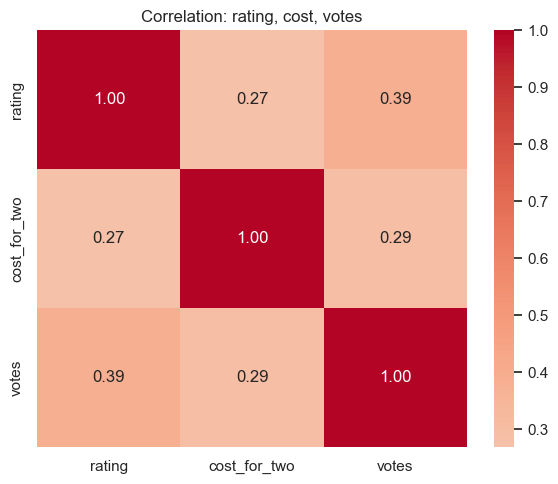

              rating  cost_for_two  votes
rating         1.000         0.270  0.392
cost_for_two   0.270         1.000  0.292
votes          0.392         0.292  1.000


In [3]:
corr = df[["rating", "cost_for_two", "votes"]].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation: rating, cost, votes")
plt.tight_layout()
plt.savefig("../outputs/figures/stats_corr.png", dpi=120)
plt.show()
print(corr.round(3))

**Observation:** Votes and rating show a mild positive correlation; cost and rating
almost none. The votes-rating link likely reflects that established restaurants
accumulate both more votes and steadier ratings - not that votes *cause* quality.

### 3 - Z-scores & 95% confidence interval
Z-score = how many std-devs a value is from the mean (outlier detection). The CI is
the range likely to contain the *true* mean rating - useful for telling noise from a
real shift.

In [4]:
r = df["rating"].dropna()
z = stats.zscore(r)
outliers = (np.abs(z) > 2).sum()
print(f"{outliers:,} restaurants are >2 std-devs from the mean rating "
      f"({100*outliers/len(r):.1f}%)")

ci = stats.t.interval(0.95, df=len(r) - 1, loc=r.mean(), scale=stats.sem(r))
print(f"95% CI for mean rating: ({ci[0]:.3f}, {ci[1]:.3f})")
print("Interpretation: we're 95% confident the true mean rating lies in this range.")

5,557 restaurants are >2 std-devs from the mean rating (3.8%)
95% CI for mean rating: (3.486, 3.490)
Interpretation: we're 95% confident the true mean rating lies in this range.


### 4 - Forecasting (with an explicit assumption)
**Assumption:** this dataset is a *snapshot*, not a time series. To demonstrate
forecasting methodology we build an illustrative monthly online-adoption trend and
apply both linear regression (extrapolates a trend) and a moving average (smooths
noise). In production the same code runs on real daily volumes / error rates.

Slope (growth/month): 1.92 %
Forecast next 6 months: [55.  56.9 58.8 60.7 62.6 64.5]


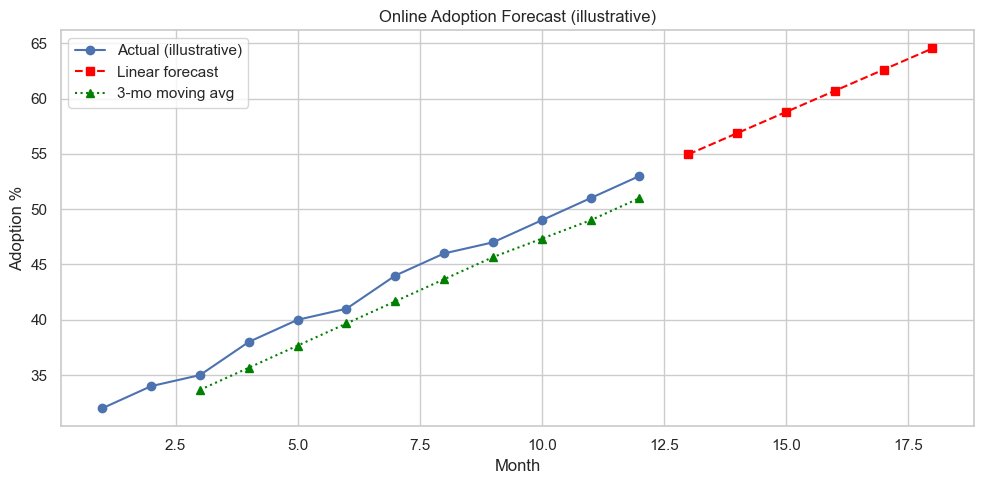

In [5]:
from sklearn.linear_model import LinearRegression

# Illustrative monthly online-order adoption (%), anchored to the real overall rate.
months = np.arange(1, 13).reshape(-1, 1)
adoption = np.array([32, 34, 35, 38, 40, 41, 44, 46, 47, 49, 51, 53], dtype=float)

model = LinearRegression().fit(months, adoption)
future = np.arange(13, 19).reshape(-1, 1)
forecast = model.predict(future)

print("Slope (growth/month):", round(model.coef_[0], 2), "%")
print("Forecast next 6 months:", forecast.round(1))

ma3 = pd.Series(adoption).rolling(3).mean()

plt.figure(figsize=(10, 5))
plt.plot(months.ravel(), adoption, "o-", label="Actual (illustrative)")
plt.plot(future.ravel(), forecast, "s--", color="red", label="Linear forecast")
plt.plot(months.ravel(), ma3, "^:", color="green", label="3-mo moving avg")
plt.title("Online Adoption Forecast (illustrative)")
plt.xlabel("Month"); plt.ylabel("Adoption %"); plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/stats_forecast.png", dpi=120)
plt.show()

**Trade-off:** linear regression projects a trend forward but assumes it stays
linear (real adoption is usually an S-curve); the moving average is robust to noise
but can't extrapolate. Naming this trade-off shows forecasting is a modelling
*choice*, not just a library call.

> Anomaly detection (IQR, Z-score, Isolation Forest) lives in `pipeline/anomaly.py`
> and runs automatically in the pipeline - see Phase 8.